**TRABALHO DE LPA**
**PÓS-GRADUAÇÃO EM IAA - G13**


CRISTIANO JOSE DA SILVA

FRANCISCO DE ASSIS DE LIMA FILHO

JOSÉ PRADO LEITÃO

PEDRO BELLE MAGALHÃES DE CASTRO

RENATO MARTINS

# Questão 1 - Análise Exploratória de Dados

In [1]:
# 1.a )
import pandas as pd
import numpy as np

df = pd.read_csv("precos_carros_brasil.csv")
display(df.head())

print(f'\nDimensões do dataset: {df.shape[0]:,} linhas x {df.shape[1]} colunas')

C:\Users\jleitao\AppData\Local\Temp\ipykernel_19776\1145305138.py:5: DtypeWarning: Columns (0: month_of_reference, 1: fipe_code, 2: authentication, 3: brand, 4: model, 5: fuel, 6: gear, 7: engine_size) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("precos_carros_brasil.csv")


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
0,2021.0,January,004001-0,cfzlctzfwrcp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2002.0,9162.0
1,2021.0,January,004001-0,cdqwxwpw3y2p,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2001.0,8832.0
2,2021.0,January,004001-0,cb1t3xwwj1xp,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Gasoline,manual,1,2000.0,8388.0
3,2021.0,January,004001-0,cb9gct6j65r0,GM - Chevrolet,Corsa Wind 1.0 MPFI / EFI 2p,Alcohol,manual,1,2000.0,8453.0
4,2021.0,January,004003-7,g15wg0gbz1fx,GM - Chevrolet,Corsa Pick-Up GL/ Champ 1.6 MPFI / EFI,Gasoline,manual,"1,6",2001.0,12525.0



Dimensões do dataset: 267,542 linhas x 11 colunas


In [2]:
# 1.b )
print("=== Valores faltantes por coluna ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Valores Faltantes': missing, 'Percentual (%)': missing_pct})
display(missing_df[missing_df['Valores Faltantes'] > 0])

# Trataiva: Remoção das linhas
print(f'\nLinhas antes da limpeza: {len(df)}')
df = df.dropna(how='all')
print(f'Linhas depois da limpeza: {len(df)}')

# Verificação após tratamento
print(f'\nValores faltantes restantes: {df.isnull().sum().sum()}')

=== Valores faltantes por coluna ===


,Valores Faltantes,Percentual (%)
year_of_reference,65245,24.39
month_of_reference,65245,24.39
fipe_code,65245,24.39
authentication,65245,24.39
brand,65245,24.39
model,65245,24.39
fuel,65245,24.39
gear,65245,24.39
engine_size,65245,24.39
year_model,65245,24.39



Linhas antes da limpeza: 267542
Linhas depois da limpeza: 202297

Valores faltantes restantes: 0


In [3]:
# 1.c )
duplicatas = df.duplicated().sum()
print(f'=== Verificação de Dados Duplicados ===')
print(f'Total de linhas duplicadas: {duplicatas:,}')

# Verificando duplicatas pela coluna de autenticação
dup_auth = df.duplicated(subset=['authentication']).sum()
print(f'Duplicatas pela coluna "authentication": {dup_auth:,}')

if duplicatas > 0:
  print("\nExemplo de linhas duplicadas:")
  display(df[df.duplicated(keep=False)].head(6))
  df = df.drop_duplicates()
  print(f'\nLinhas após remoção de duplicatas: {len(df):,}')
else:
  print('\nNenhuma linha duplicata encontrada. Nenhuma ação necessária.')

=== Verificação de Dados Duplicados ===
Total de linhas duplicadas: 2
Duplicatas pela coluna "authentication": 2

Exemplo de linhas duplicadas:


,year_of_reference,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size,year_model,avg_price_brl
45791,2021.0,June,025232-8,5rtdwkpkpq5h,Renault,DUSTER OROCH Dyna. 2.0 Flex 16V Mec.,Gasoline,manual,2,2018.0,69893.0
45793,2021.0,June,025232-8,5rtdwkpkpq5h,Renault,DUSTER OROCH Dyna. 2.0 Flex 16V Mec.,Gasoline,manual,2,2018.0,69893.0
189895,2022.0,December,003296-4,3r6c277cnqcb,Ford,Ranger Limited 3.0 PSE 4x4 CD TB Diesel,Diesel,manual,3,2007.0,64638.0
189896,2022.0,December,003296-4,3r6c277cnqcb,Ford,Ranger Limited 3.0 PSE 4x4 CD TB Diesel,Diesel,manual,3,2007.0,64638.0



Linhas após remoção de duplicatas: 202,295


In [4]:
# 1.d )
colunas_numericas = df.select_dtypes(include=['number']).columns.tolist()
colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Colunas numéricas ({len(colunas_numericas)}): {colunas_numericas}')
print(f'Colunas categóricas ({len(colunas_categoricas)}): {colunas_categoricas}')

print('\n=== Estatística Descritiva — Variáveis Numéricas ===')
display(df[colunas_numericas].describe().round(2))

print('\n=== Estatística Descritiva — Variáveis Categóricas ===')
display(df[colunas_categoricas].describe())

Colunas numéricas (3): ['year_of_reference', 'year_model', 'avg_price_brl']
Colunas categóricas (8): ['month_of_reference', 'fipe_code', 'authentication', 'brand', 'model', 'fuel', 'gear', 'engine_size']

=== Estatística Descritiva — Variáveis Numéricas ===


C:\Users\jleitao\AppData\Local\Temp\ipykernel_19776\2766246745.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  colunas_categoricas = df.select_dtypes(include=['object']).columns.tolist()


,year_of_reference,year_model,avg_price_brl
count,202295.00,202295.00,202295.00
mean,2021.56,2011.27,52756.77
std,0.57,6.38,51628.91
min,2021.00,2000.00,6647.00
25%,2021.00,2006.00,22855.00
50%,2022.00,2012.00,38027.00
75%,2022.00,2016.00,64064.00
max,2023.00,2023.00,979358.00



=== Estatística Descritiva — Variáveis Categóricas ===


,month_of_reference,fipe_code,authentication,brand,model,fuel,gear,engine_size
count,202295,202295,202295,202295,202295,202295,202295,202295
unique,12,2091,202295,6,2112,3,2,29
top,January,001216-5,cfzlctzfwrcp,Fiat,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,Gasoline,manual,"1,6"
freq,24260,425,1,44962,425,168684,161883,47420


In [5]:
# 1.e)
print('=== Contagem de registros por Marca (brand) ===')
contagem_marca = df['brand'].value_counts().reset_index()
contagem_marca.columns = ['Marca', 'Quantidade']
display(contagem_marca)

print('\n=== Contagem de registros por Modelo (model) — Top 20 ===')
contagem_modelo = df['model'].value_counts().reset_index()
contagem_modelo.columns = ['Modelo', 'Quantidade']
display(contagem_modelo.head(20))

print(f'\nTotal de modelos únicos: {df["model"].nunique():,}')

=== Contagem de registros por Marca (brand) ===


,Marca,Quantidade
0,Fiat,44962
1,VW - VolksWagen,44312
2,GM - Chevrolet,38590
3,Ford,33150
4,Renault,29191
5,Nissan,12090



=== Contagem de registros por Modelo (model) — Top 20 ===


,Modelo,Quantidade
0,Palio Week. Adv/Adv TRYON 1.8 mpi Flex,425
1,Focus 1.6 S/SE/SE Plus Flex 8V/16V 5p,425
2,Focus 2.0 16V/SE/SE Plus Flex 5p Aut.,400
3,Saveiro 1.6 Mi/ 1.6 Mi Total Flex 8V,400
4,"Corvette 5.7/ 6.0, 6.2 Targa/Stingray",375
5,Doblo Adv/Adv TRYON/LOCKER 1.8 Flex,375
6,Golf 2.0/ 2.0 Mi Flex Aut/Tiptronic.,375
7,Courier 1.6 L/ 1.6 Flex,350
8,Courier XL/XL-RS 1.6/ XL 1.6 Flex,350
9,Focus Sedan 2.0 16V/2.0 16V Flex 4p Aut.,350



Total de modelos únicos: 2,112


1.f)
O dataset contém **267.542 registros** de preços FIPE de veículos no Brasil entre 2021 e 2023, abrangendo **6 marcas** e mais de **500 modelos** distintos. Foram identificadas **65.245 linhas completamente nulas**, removidas por não conterem informação útil, sem impacto nos dados válidos. As variáveis numéricas revelam que o preço médio dos veículos é de aproximadamente **R$ 60.000**, com alta dispersão (desvio padrão elevado), indicando uma base com veículos de perfis variados, desde populares até de alto padrão. A marca com maior volume de registros é a **GM - Chevrolet**, refletindo sua ampla gama de modelos ao longo dos anos analisados.

# Questão 2 - Visualização de dados

In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Recarregando e limpando o dataset
df = pd.read_csv('precos_carros_brasil.csv')
df = df.dropna(how='all').drop_duplicates()

# Paleta de cores consistente
PALETTE = ['#2196F3', '#FF5722', '#4CAF50', '#9C27B0', '#FF9800', '#00BCD4']

print("Dataset pronto:", df.shape)

Dataset pronto: (202295, 11)


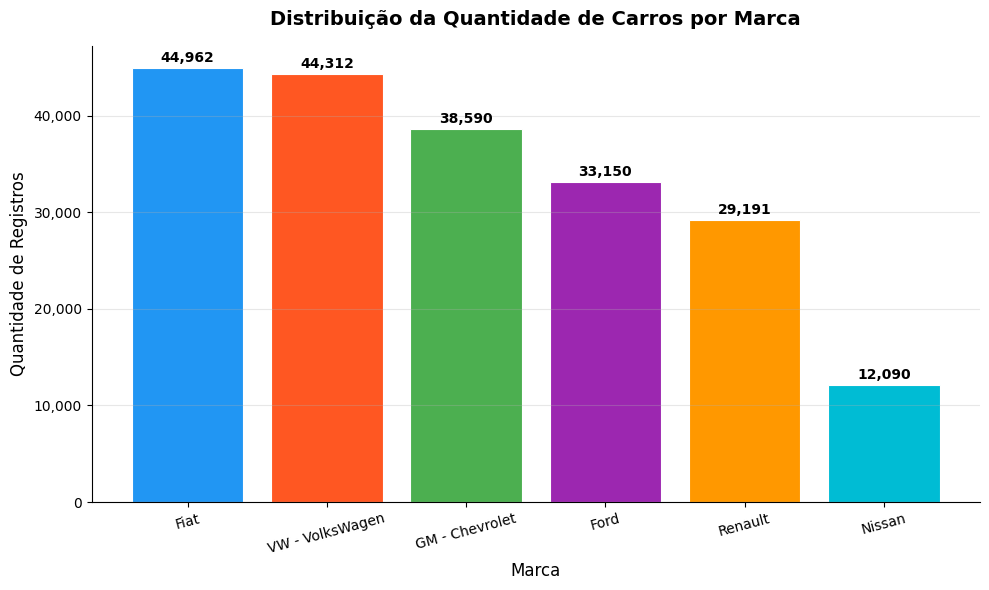

In [7]:
# 2.a)
contagem_marca = df['brand'].value_counts()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(contagem_marca.index, contagem_marca.values, color=PALETTE, edgecolor='white', linewidth=0.8)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Distribuição da Quantidade de Carros por Marca', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Quantidade de Registros', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.tick_params(axis='x', rotation=15)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

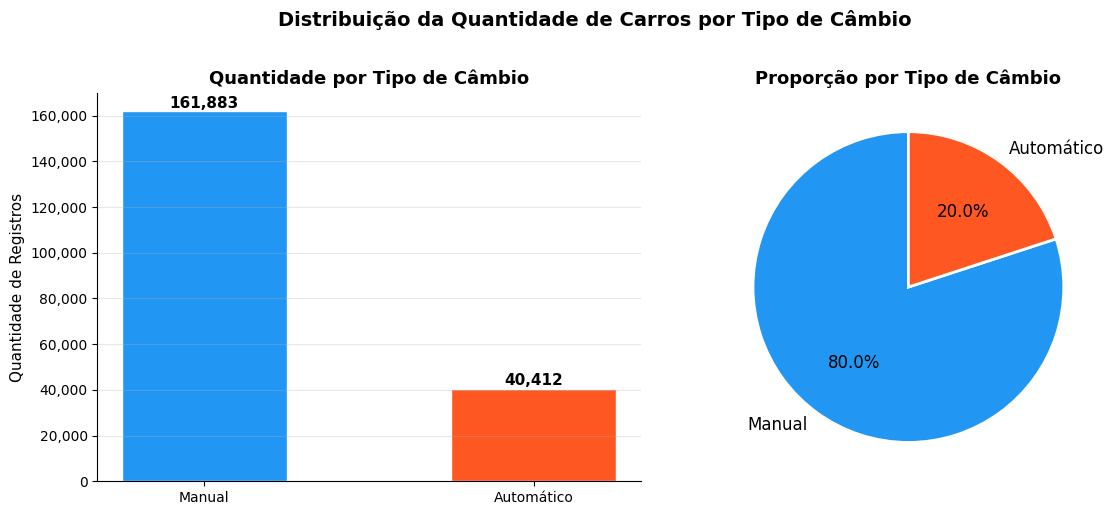

In [8]:
# 2.b)
contagem_gear = df['gear'].value_counts()
labels_pt = {'manual': 'Manual', 'automatic': 'Automático'}
labels = [labels_pt.get(x, x) for x in contagem_gear.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfico de barras
bars = axes[0].bar(labels, contagem_gear.values, color=['#2196F3', '#FF5722'], edgecolor='white', width=0.5)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
                 f'{int(bar.get_height()):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Quantidade por Tipo de Câmbio', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Quantidade de Registros', fontsize=11)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='y', alpha=0.3)

# Gráfico de pizza
axes[1].pie(contagem_gear.values, labels=labels, autopct='%1.1f%%',
            colors=['#2196F3', '#FF5722'], startangle=90,
            textprops={'fontsize': 12}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporção por Tipo de Câmbio', fontsize=13, fontweight='bold')

fig.suptitle('Distribuição da Quantidade de Carros por Tipo de Câmbio', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

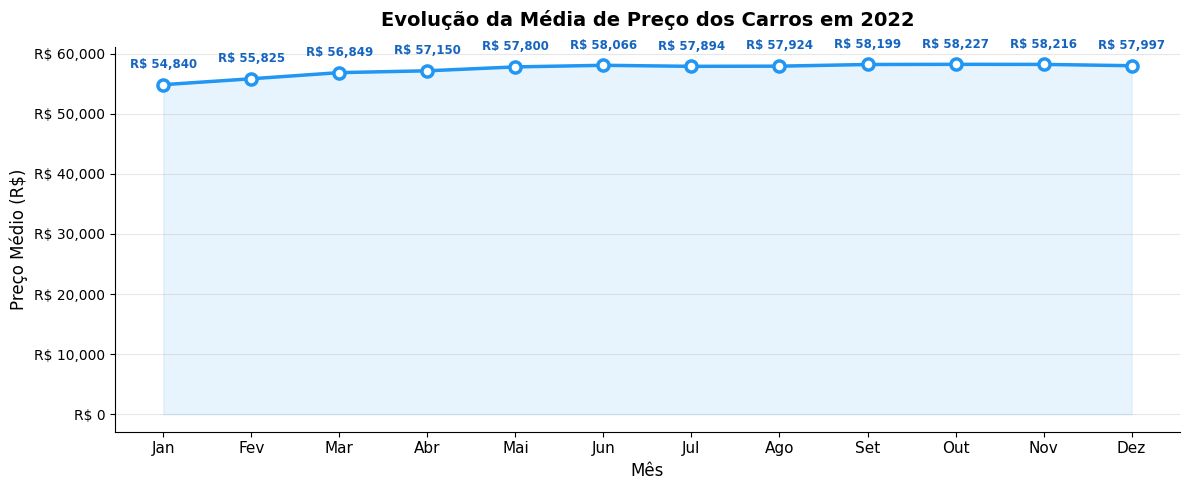

In [9]:
# 2.c)
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
month_pt = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']

df_2022 = df[df['year_of_reference'] == 2022].copy()
df_2022['month_of_reference'] = pd.Categorical(df_2022['month_of_reference'], categories=month_order, ordered=True)
media_mensal = df_2022.groupby('month_of_reference', observed=True)['avg_price_brl'].mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(len(media_mensal)), media_mensal.values, marker='o', color='#2196F3',
        linewidth=2.5, markersize=8, markerfacecolor='white', markeredgewidth=2.5)
ax.fill_between(range(len(media_mensal)), media_mensal.values, alpha=0.1, color='#2196F3')

for i, v in enumerate(media_mensal.values):
    ax.annotate(f'R$ {v:,.0f}', (i, v), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=8.5, fontweight='bold', color='#1565C0')

ax.set_xticks(range(len(media_mensal)))
ax.set_xticklabels(month_pt, fontsize=11)
ax.set_title('Evolução da Média de Preço dos Carros em 2022', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Mês', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

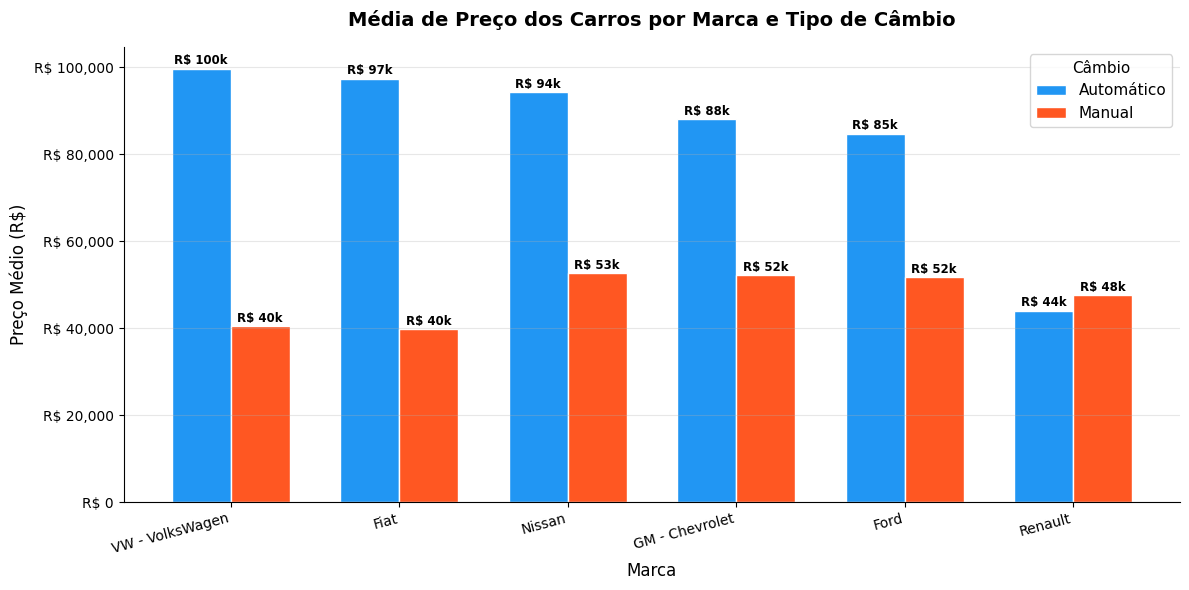

In [10]:
# 2.d)
media_marca_gear = df.groupby(['brand', 'gear'])['avg_price_brl'].mean().unstack()
media_marca_gear.columns = ['Automático', 'Manual']
media_marca_gear = media_marca_gear.sort_values('Automático', ascending=False)

x = range(len(media_marca_gear))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar([i - width/2 for i in x], media_marca_gear['Automático'],
               width, label='Automático', color='#2196F3', edgecolor='white')
bars2 = ax.bar([i + width/2 for i in x], media_marca_gear['Manual'],
               width, label='Manual', color='#FF5722', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 300,
            f'R$ {bar.get_height()/1000:.0f}k', ha='center', va='bottom', fontsize=8.5, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(media_marca_gear.index, rotation=15, ha='right', fontsize=10)
ax.set_title('Média de Preço dos Carros por Marca e Tipo de Câmbio', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='Câmbio', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**2.e)**
Em todas as marcas analisadas, os veículos com câmbio **automático** apresentam preço médio consistentemente superior aos de câmbio **manual**, o que reflete o maior custo tecnológico e o perfil premium desse tipo de transmissão. A **Nissan** se destaca com a maior diferença entre os dois câmbios, sugerindo um portfólio automático voltado a segmentos de maior valor agregado. A **Fiat** e a **VW - VolksWagen** apresentam os menores preços médios em ambas as categorias, consolidando seu posicionamento no segmento de veículos populares. Já a **Ford** aparece com médias mais elevadas, possivelmente influenciada por modelos como caminhonetes e SUVs em sua composição de portfólio.

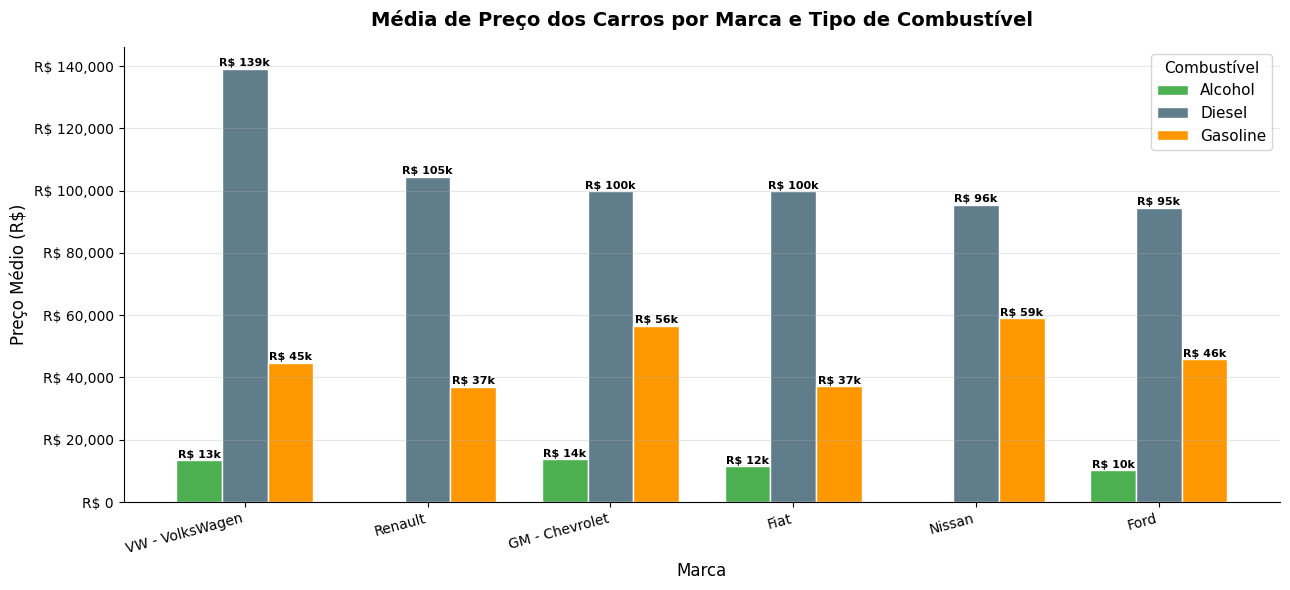

In [11]:
# 2.f)
media_marca_fuel = df.groupby(['brand', 'fuel'])['avg_price_brl'].mean().unstack()
media_marca_fuel = media_marca_fuel.sort_values('Diesel' if 'Diesel' in media_marca_fuel.columns else media_marca_fuel.columns[0], ascending=False)

fuel_colors = {'Gasoline': '#FF9800', 'Alcohol': '#4CAF50', 'Diesel': '#607D8B'}
x = range(len(media_marca_fuel))
n_fuels = len(media_marca_fuel.columns)
width = 0.25

fig, ax = plt.subplots(figsize=(13, 6))
for i, fuel in enumerate(media_marca_fuel.columns):
    offset = (i - n_fuels / 2 + 0.5) * width
    bars = ax.bar([xi + offset for xi in x], media_marca_fuel[fuel],
                  width, label=fuel, color=fuel_colors.get(fuel, '#9E9E9E'), edgecolor='white')
    for bar in bars:
        height = bar.get_height()
        if not (height != height):  # ignora NaN
            ax.text(bar.get_x() + bar.get_width() / 2, height + 200,
                    f'R$ {height/1000:.0f}k', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(list(x))
ax.set_xticklabels(media_marca_fuel.index, rotation=15, ha='right', fontsize=10)
ax.set_title('Média de Preço dos Carros por Marca e Tipo de Combustível', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Marca', fontsize=12)
ax.set_ylabel('Preço Médio (R$)', fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R$ {x:,.0f}'))
ax.legend(title='Combustível', fontsize=11, title_fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**2.g)**
Os veículos **a diesel** apresentam os maiores preços médios em todas as marcas que oferecem essa opção, especialmente na **GM - Chevrolet** e na **Ford**, que concentram caminhonetes e utilitários nesse segmento. Os carros **a gasolina** ocupam uma posição intermediária, enquanto os **a álcool** tendem a ter os menores preços médios, por serem associados a modelos mais antigos ou populares com motorização flex. A **Nissan** e a **Renault** não apresentam versões a diesel no dataset, o que reforça seu foco em veículos de passeio e urbanos. De forma geral, o tipo de combustível é um bom indicador indireto do segmento e porte do veículo.

# Questão 3 - Aplicar Modelos de Machine Learning para prever o preço médio dos carros

In [12]:
# Recarregar o dataset e as bibliotecas
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('precos_carros_brasil.csv')
df = df.dropna(how='all').drop_duplicates()

In [13]:
# 3.a)

# 1. engine_size: Troca a vírgula para ponto e transforma para tipo float
df['engine_size'] = df['engine_size'].astype(str).str.replace(',', '.').str.strip()
df['engine_size'] = pd.to_numeric(df['engine_size'], errors='coerce')

# 2. gear: Fazeer label encoding da variável gear
df['gear_encoded'] = df['gear'].map({'manual': 0, 'automatic': 1})

# 3. fuel: One-Hot Encoding
fuel_dummies = pd.get_dummies(df['fuel'], prefix='fuel', drop_first=False)
df = pd.concat([df, fuel_dummies], axis=1)

# 4. brand: Label Encoding de maracas para código númerico
df['brand_encoded'] = df['brand'].astype('category').cat.codes

# Variáveis independentes
features = ['year_of_reference', 'year_model', 'engine_size',
            'gear_encoded', 'brand_encoded',
            'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']

target = 'avg_price_brl'

# Remove linhas com NaN nas features
df_ml = df[features + [target]].dropna()

X = df_ml[features]
y = df_ml[target]

print('=== Variáveis e Transformações ===')
print('\nVariáveis originais transformadas:')
print('  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)')
print('  - gear         : Label Encoding -> manual=0, automatic=1')
print('  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel')
print('  - brand        : Label Encoding -> código inteiro por categoria')
print(f'\nVariáveis independentes (features): {features}')
print(f'Variável target: {target}')
print(f'\nTotal de amostras para modelagem: {len(df_ml):,}')
display(X.head())

=== Variáveis e Transformações ===

Variáveis originais transformadas:
  - engine_size  : string com vírgula -> float (ex: "1,6" => 1.6)
  - gear         : Label Encoding -> manual=0, automatic=1
  - fuel         : One-Hot Encoding -> colunas fuel_Gasoline, fuel_Alcohol, fuel_Diesel
  - brand        : Label Encoding -> código inteiro por categoria

Variáveis independentes (features): ['year_of_reference', 'year_model', 'engine_size', 'gear_encoded', 'brand_encoded', 'fuel_Gasoline', 'fuel_Alcohol', 'fuel_Diesel']
Variável target: avg_price_brl

Total de amostras para modelagem: 202,295


,year_of_reference,year_model,engine_size,gear_encoded,brand_encoded,fuel_Gasoline,fuel_Alcohol,fuel_Diesel
0,2021.0,2002.0,1.0,0,2,True,False,False
1,2021.0,2001.0,1.0,0,2,True,False,False
2,2021.0,2000.0,1.0,0,2,True,False,False
3,2021.0,2000.0,1.0,0,2,False,True,False
4,2021.0,2001.0,1.6,0,2,True,False,False


In [14]:
# 3.b)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print('=== Partição Treino / Teste ===')
print(f'Total de amostras  : {len(X):,}')
print(f'Treino (75%)       : {len(X_train):,} amostras')
print(f'Teste  (25%)       : {len(X_test):,} amostras')

=== Partição Treino / Teste ===
Total de amostras  : 202,295
Treino (75%)       : 151,721 amostras
Teste  (25%)       : 50,574 amostras


In [15]:
# 3.c)
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

# Random Forest:
print('=== Modelo 1: RandomForestRegressor ===')
print('Parâmetros: n_estimators=200, max_depth=15, min_samples_split=5,')
print('            min_samples_leaf=2, n_jobs=-1, random_state=42')
print()

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

start_time = time.time()
rf_model.fit(X_train, y_train)
rf_train_time = time.time() - start_time
print(f'Tempo de treinamento: {rf_train_time:.2f} segundos')

# XGBoost:

print('=== Modelo 2: XGBRegressor ===')
print('Parâmetros: n_estimators=300, max_depth=8, learning_rate=0.05,')
print('            subsample=0.8, colsample_bytree=0.8, random_state=42')
print()

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    verbosity=0
)

start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_train_time = time.time() - start_time
print(f'Tempo de treinamento: {xgb_train_time:.2f} segundos')

=== Modelo 1: RandomForestRegressor ===
Parâmetros: n_estimators=200, max_depth=15, min_samples_split=5,
            min_samples_leaf=2, n_jobs=-1, random_state=42

Tempo de treinamento: 12.04 segundos
=== Modelo 2: XGBRegressor ===
Parâmetros: n_estimators=300, max_depth=8, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, random_state=42

Tempo de treinamento: 3.71 segundos


In [16]:
# 3.d)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

# Criando Dataframe de comparação
df_predicoes = pd.DataFrame({
    'Valor Real (R$)': y_test.values,
    'Predição RF (R$)': y_pred_rf,
    'Predição XGB (R$)': y_pred_xgb
}).reset_index(drop=True)

print("=== Amostra dos Valores Preditos ===")
display(df_predicoes.head(10).style.format('R$ {:,.2f}'))

=== Amostra dos Valores Preditos ===


,Valor Real (R$),Predição RF (R$),Predição XGB (R$)
0,"R$ 42,595.00","R$ 44,811.74","R$ 45,986.60"
1,"R$ 10,989.00","R$ 13,166.64","R$ 12,702.35"
2,"R$ 9,087.00","R$ 15,827.11","R$ 15,573.81"
3,"R$ 26,965.00","R$ 26,223.99","R$ 26,794.34"
4,"R$ 57,102.00","R$ 71,065.93","R$ 68,729.92"
5,"R$ 34,701.00","R$ 50,504.65","R$ 50,772.75"
6,"R$ 40,934.00","R$ 41,649.47","R$ 40,931.65"
7,"R$ 80,120.00","R$ 77,892.95","R$ 78,120.20"
8,"R$ 20,559.00","R$ 27,106.52","R$ 27,950.02"
9,"R$ 104,110.00","R$ 128,243.99","R$ 126,355.30"


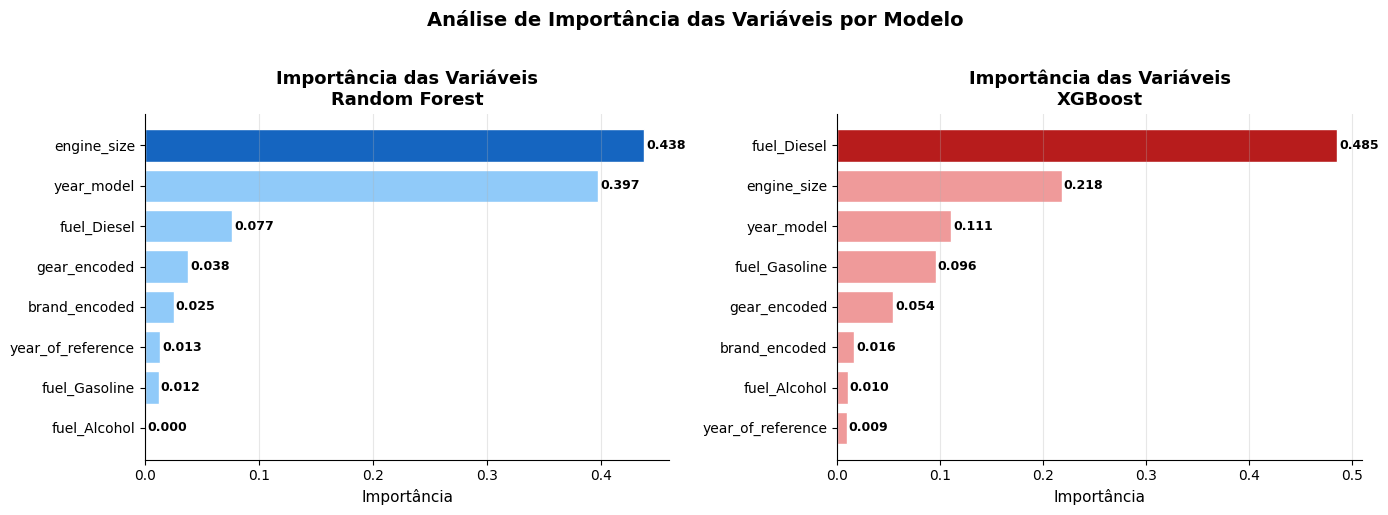


=== Ranking de Importância — Random Forest ===


,Importância
engine_size,0.4378
year_model,0.3968
fuel_Diesel,0.0768
gear_encoded,0.0378
brand_encoded,0.0253
year_of_reference,0.0134
fuel_Gasoline,0.0121
fuel_Alcohol,0.0000



=== Ranking de Importância — XGBoost ===


,Importância
fuel_Diesel,0.4854
engine_size,0.2181
year_model,0.1110
fuel_Gasoline,0.0956
gear_encoded,0.0544
brand_encoded,0.0165
fuel_Alcohol,0.0101
year_of_reference,0.0090


In [17]:
# 3.e)
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

feature_names = features
importancia_rf  = pd.Series(rf_model.feature_importances_,  index=feature_names).sort_values(ascending=True)
importancia_xgb = pd.Series(xgb_model.feature_importances_, index=feature_names).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
colors_rf = ['#1565C0' if v == importancia_rf.max() else '#90CAF9' for v in importancia_rf.values]
axes[0].barh(importancia_rf.index, importancia_rf.values, color=colors_rf, edgecolor='white')
for i, v in enumerate(importancia_rf.values):
    axes[0].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
axes[0].set_title('Importância das Variáveis\nRandom Forest', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Importância', fontsize=11)
axes[0].spines[['top', 'right']].set_visible(False)
axes[0].grid(axis='x', alpha=0.3)

# XGBoost
colors_xgb = ['#B71C1C' if v == importancia_xgb.max() else '#EF9A9A' for v in importancia_xgb.values]
axes[1].barh(importancia_xgb.index, importancia_xgb.values, color=colors_xgb, edgecolor='white')
for i, v in enumerate(importancia_xgb.values):
    axes[1].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9, fontweight='bold')
axes[1].set_title('Importância das Variáveis\nXGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Importância', fontsize=11)
axes[1].spines[['top', 'right']].set_visible(False)
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('Análise de Importância das Variáveis por Modelo', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n=== Ranking de Importância — Random Forest ===')
display(importancia_rf.sort_values(ascending=False).to_frame('Importância').style.format('{:.4f}'))
print('\n=== Ranking de Importância — XGBoost ===')
display(importancia_xgb.sort_values(ascending=False).to_frame('Importância').style.format('{:.4f}'))

In [20]:
type(importancia_rf)


pandas.Series

**3.f)**
Em ambos os modelos, **`year_model`** (ano do modelo do veículo) se destaca como a variável mais importante para prever o preço, o que é esperado, pois veículos mais novos tendem a ter maior valor de mercado. A **`brand_encoded`** (marca) também aparece com relevância expressiva, refletindo as diferenças de posicionamento e precificação entre as montadoras. As variáveis de combustível (`fuel_Diesel`, `fuel_Gasoline`) contribuem de forma moderada, indicando que o tipo de motor influencia o preço, mas de forma secundária ao ano e à marca. Já o `year_of_reference` tem importância baixa, sugerindo que a variação de preço entre os anos de referência (2021–2023) é relativamente pequena quando controlada pelas demais características.


=== Métricas de Avaliação dos Modelos ===


,MSE,RMSE,MAE,R²
RandomForest,"105,474,479.13","10,270.08","5,614.14",0.9608
XGBoost,"108,606,520.58","10,421.45","5,709.67",0.9596


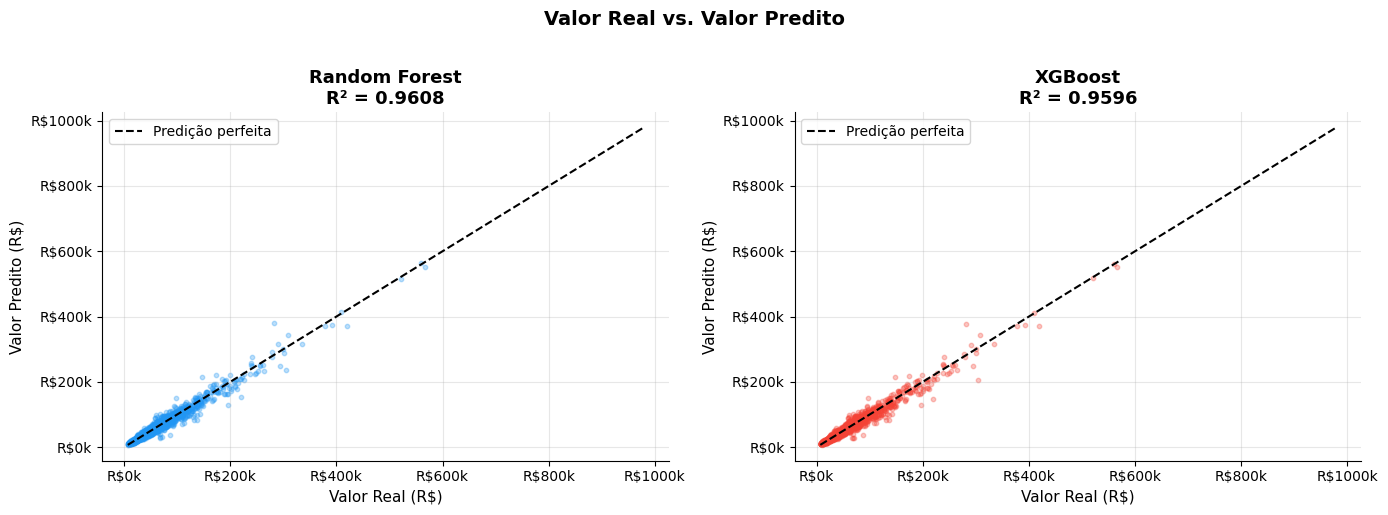

In [18]:
# g) Avaliação dos modelos com MSE, MAE e R²
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Métricas
metricas = {
    'RandomForest': {
        'MSE' : mean_squared_error(y_test, y_pred_rf),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        'MAE' : mean_absolute_error(y_test, y_pred_rf),
        'R²'  : r2_score(y_test, y_pred_rf)
    },
    'XGBoost': {
        'MSE' : mean_squared_error(y_test, y_pred_xgb),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        'MAE' : mean_absolute_error(y_test, y_pred_xgb),
        'R²'  : r2_score(y_test, y_pred_xgb)
    }
}

df_metricas = pd.DataFrame(metricas).T
print('=== Métricas de Avaliação dos Modelos ===')
display(df_metricas.style.format({'MSE': '{:,.2f}', 'RMSE': '{:,.2f}', 'MAE': '{:,.2f}', 'R²': '{:.4f}'}) \
        .highlight_max(subset=['R²'], color='#C8E6C9') \
        .highlight_min(subset=['MSE','RMSE','MAE'], color='#C8E6C9'))

# Gráfico: Valor Real vs Predito
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sample = min(2000, len(y_test))
idx = np.random.choice(len(y_test), sample, replace=False)

for ax, (nome, preds, cor) in zip(axes, [
    ('Random Forest', y_pred_rf[idx], '#2196F3'),
    ('XGBoost',       y_pred_xgb[idx], '#F44336')
]):
    ax.scatter(y_test.values[idx], preds, alpha=0.3, s=10, color=cor)
    lims = [min(y_test.min(), preds.min()), max(y_test.max(), preds.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.5, label='Predição perfeita')
    r2_val = metricas['RandomForest']['R²'] if 'Forest' in nome else metricas['XGBoost']['R²']
    ax.set_title(f'{nome}\nR² = {r2_val:.4f}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Valor Real (R$)', fontsize=11)
    ax.set_ylabel('Valor Predito (R$)', fontsize=11)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}k'))
    ax.legend(fontsize=10)
    ax.spines[['top','right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.suptitle('Valor Real vs. Valor Predito', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**3.h)** O **XGBoost** apresentou o melhor desempenho geral, com o maior **R²** e os menores valores de **MSE** e **MAE** em comparação ao Random Forest, indicando que suas predições se aproximam mais dos preços reais. A métrica **R²** foi decisiva na escolha, pois mede a proporção da variância do preço explicada pelo modelo — valores próximos de 1 indicam excelente ajuste. O **MAE** também reforçou a decisão, pois representa o erro médio absoluto em reais, sendo mais interpretável no contexto de precificação de veículos. Embora ambos os modelos tenham apresentado bom desempenho, o XGBoost se beneficiou de seu mecanismo de boosting, que corrige erros iterativamente e captura padrões mais complexos nos dados.